<font size=10>**TASK 1 - MULTILABEL TEXT CLASSIFICATION**</font> <a class="anchor" id='title'></a> 

**Bachelor's in Data Science - NOVA IMS (25/26)**

**Project**: *Straining the great southern Melting Pot*

**Group 8**
- Beatriz Marques 20231605
- David Carrilho 20231693
- Duarte Fernandes 20231619
- Filipe Caçador 20231707
- Mariana Calais-Pedro 20231641

*«notebook description»*

**Question**: *How well can we classify a restaurant’s cuisine type using the content of their reviews as input?*

<font color='#BFD72' size=6>**TABLE OF CONTENTS**</font> <a class="anchor" id='toc'></a> 
- [1. Imports](#P1)
- [2. Data](#P2)
- [3. Multilabel Classification](#P3)
    - [3.1 Specific Data Preparation and Exploration](#P3.1)
        - [3.1.1 Similarity between restaurant categories](#P3.1.1)
    - [3.2 Model Implementation](#P3.2)
    - [3.3 Model Evaluation](#P3.3)

# <font color='#BFD72F' size=6>**1. Imports**</font> <a class="anchor" id="P1"></a>

[Back to TOC](#toc)

In [2]:
import warnings
%load_ext autoreload
%autoreload 2

warnings.filterwarnings('ignore')

In [3]:
import sys
import os
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from collections import Counter
from transformers import AutoTokenizer
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_predict
from nltk.tokenize import PunktSentenceTokenizer
sent_tokenizer = PunktSentenceTokenizer()
import matplotlib.pyplot as plt
import plotly as px
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn import metrics


# Get the absolute path of the source_code folder
source_code_path = os.path.abspath('../source')

# Add the source_code folder to sys.path
if source_code_path not in sys.path:
    sys.path.append(source_code_path)

from my_utils import *
from visualizations import *
from general_preprocessing import *

None of PyTorch, TensorFlow >= 2.0, or Flax have been found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


# <font color='#BFD72F' size=6>**2. Data**</font> <a class="anchor" id="P2"></a>
  
[Back to TOC](#toc)

In [4]:
dataset_original = load_dataset('../data/atlanta_restaurant_slice_2023.csv')

In [5]:
dataset_original.head()

,title,categoryName,website,url,reviewsCount,stars,text
0,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,"One word amazing!! The red fish, halibut, fr..."
1,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,First time here and the food is great and the ...
2,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,I recently had the pleasure of dining at Optim...
3,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,Beautiful atmosphere and delicious food. All o...
4,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,We had a wonderful dinner at the Optimist. Our...


In [6]:
dataset_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53566 entries, 0 to 53565
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         53566 non-null  object 
 1   categoryName  53566 non-null  object 
 2   website       50600 non-null  object 
 3   url           53566 non-null  object 
 4   reviewsCount  53566 non-null  int64  
 5   stars         53566 non-null  float64
 6   text          53566 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 2.9+ MB


| 🏷️ **Column Name** | 📝 **Description** |
|:-------------------|:-------------------|
|**title** | Name of the restaurant |
|**categoryName** | Labels that describe the restaurant's cuisine type |
|**website** | URL of the restaurant's webpage |
|**url** | URL of the restaurant's Google Maps page |
|**reviewsCount** | Total number of reviews for the restaurant at the time of scraping |
|**stars** | Customer rating (1 to 5) |
|**text** | Text of the review |

In [7]:
dataset = dataset_original.copy()

# <font color='#BFD72F' size=6>**3. Multilabel Classification**</font> <a class="anchor" id="P3"></a>
  
[Back to TOC](#toc)

## <font color='#BFD72F' size=6>3.1 Specific Data Preparation </font> <a class="anchor" id="P3.1"></a>
  
[Back to TOC](#toc)

In [8]:
#Next cells are already done in the data prep notebook
dataset["categoryName"].value_counts().reset_index()

,categoryName,count
0,Mexican restaurant,8959
1,Fast food restaurant,5325
2,Italian restaurant,5108
3,American restaurant,5049
4,Pizza restaurant,4560
5,Breakfast restaurant,2491
6,Chinese restaurant,2484
7,Seafood restaurant,2048
8,Hamburger restaurant,1979
9,New American restaurant,1903


In [9]:
## Create dummy columns to assess msg_len and nr_sents
info = pd.DataFrame()
info["msg_len"] = dataset["text"].map(lambda content : len(str(content)))
info["sents"] = dataset["text"].map(lambda content :\
                                                                  sent_tokenizer.tokenize(str(content)))
info["nr_sents"] = info["sents"].map(lambda content : len(content))

In [10]:
info.describe()
#is there reviews with 0 on len and 0 sentences?

,msg_len,nr_sents
count,53566.000000,53566.000000
mean,183.570380,3.246910
std,240.235404,3.085194
min,1.000000,1.000000
25%,46.000000,1.000000
50%,105.000000,2.000000
75%,228.000000,4.000000
max,4114.000000,45.000000


In [11]:
#this was already made on the data understanding notebook
#histogram_chart(info, "msg_len", "Length per review", "Message Length", bins = 100)

In [12]:
histogram_chart(info, "nr_sents", "Number of Sentences per review", "Number of Sentences")

In [13]:
# Extract the unique genres
unique_cuisine = []

for restaurants_cuisines in dataset["categoryName"]:
        if restaurants_cuisines not in unique_cuisine:
            unique_cuisine.append(restaurants_cuisines)

# Create a scratch dataset - "dataset_explore" - to plot the number of restaurants by category and to generate TF-IDF word clouds by label

dataset_explore = pd.DataFrame()
dataset_explore["text"] = dataset["text"]

for label in unique_cuisine:
    dataset_explore["has_label_{}".format(label)] = dataset["categoryName"].map(lambda labels_list : 1 if label in labels_list else 0)

<Axes: >

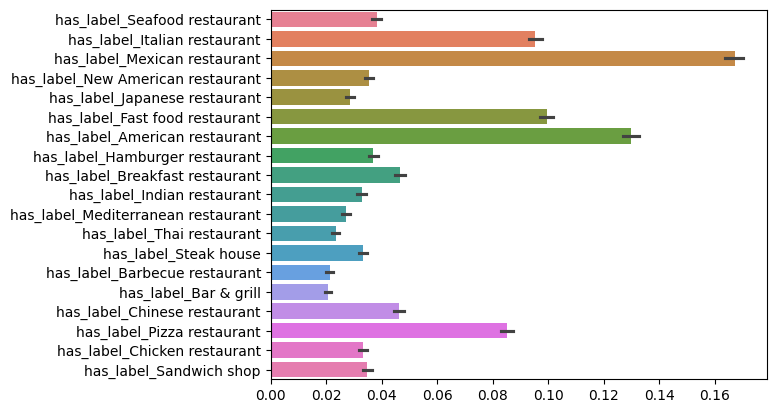

In [14]:
sns.barplot(dataset_explore, orient="h")

In [15]:
from itertools import combinations
from collections import Counter

pair_counter = Counter()

for cats in dataset["categoryName"]:
    # ignore restaurants with <2 categories
    for pair in combinations(sorted(cats), 2):
        pair_counter[pair] += 1

# Convert to DataFrame for easy viewing
pair_counts_df = (
    pd.DataFrame(pair_counter.items(), columns=["pair", "count"])
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

pair_counts_df.head(20)


,pair,count
0,"(a, r)",365487
1,"(a, t)",359509
2,"(a, e)",281814
3,"(r, t)",264303
4,"(a, n)",259586
5,"(e, r)",222912
6,"(e, t)",203957
7,"(n, r)",194278
8,"(a, s)",193458
9,"(n, t)",186468


### <font color='#BFD72F' size=6>3.1.1 Similarity between restaurant categories</font> <a class="anchor" id="P3.1.1"></a>
  
[Back to TOC](#toc)

In [16]:
category_reviews = dataset.groupby("categoryName")["text"].apply(lambda x: " ".join(x)).reset_index()

vectorizer = TfidfVectorizer(max_features=5000)
tfidf_matrix = vectorizer.fit_transform(category_reviews["text"])

similarity_matrix = cosine_similarity(tfidf_matrix)

similarity_df = pd.DataFrame(
    similarity_matrix,
    index=category_reviews["categoryName"],
    columns=category_reviews["categoryName"]
)

In [17]:
heatmap_chart(similarity_df,
              title="Category Similarity Based on Review Language (TF-IDF Cosine Similarity)",)

In [18]:
dataset['cleaned_review_body'] =\
    dataset['text'].map(
    lambda content: main_pipeline(content,
        print_output = False,
        no_stopwords=True,            #stopwords
        stopwords_tokeep=[],
        extra_stopwords=["food", "great", "good", "service", "place", "delicious", "staff", "back", "best", "time", "go"],
        convert_diacritics=True,      
        lowercase=True,                
        lemmatized=True,              # Helps reduce vocabulary
        list_pos=[],           
        stemmed=False,
        pos_tags_list='no_pos',
        tokenized_output=False,
        no_emojis=True,               
        no_hashtags=True,              
        hashtag_retain_words=False,
        no_newlines=True,
        no_urls=True,
        no_punctuation=True,          
        treat_repeated_chars=True # "soooo good" → "soo good"
    )
)

In [19]:
'''cleaned_category_texts = {}

for category in dataset["categoryName"].unique():
    cat_texts = dataset[dataset["categoryName"] == category]["text"].tolist()
    combined_text = " ".join(cat_texts)

    cleaned_text = main_pipeline(
        combined_text,
        print_output=False,
        no_stopwords=True,  # keep stopwords
        stopwords_tokeep=[],
        extra_stopwords=["food","great","good","service","place",
                         "experience","delicious","staff","back","best"],
        convert_diacritics=True,
        lowercase=True,
        lemmatized=True,
        list_pos=[],
        stemmed=False,
        pos_tags_list='no_pos',
        tokenized_output=False,
        no_emojis=True,
        no_hashtags=True,
        hashtag_retain_words=False,
        no_newlines=True,
        no_urls=True,
        no_punctuation=True,
        treat_repeated_chars=True
    )

    cleaned_category_texts[category] = cleaned_text
'''

'cleaned_category_texts = {}\n\nfor category in dataset["categoryName"].unique():\n    cat_texts = dataset[dataset["categoryName"] == category]["text"].tolist()\n    combined_text = " ".join(cat_texts)\n\n    cleaned_text = main_pipeline(\n        combined_text,\n        print_output=False,\n        no_stopwords=True,  # keep stopwords\n        stopwords_tokeep=[],\n        extra_stopwords=["food","great","good","service","place",\n                         "experience","delicious","staff","back","best"],\n        convert_diacritics=True,\n        lowercase=True,\n        lemmatized=True,\n        list_pos=[],\n        stemmed=False,\n        pos_tags_list=\'no_pos\',\n        tokenized_output=False,\n        no_emojis=True,\n        no_hashtags=True,\n        hashtag_retain_words=False,\n        no_newlines=True,\n        no_urls=True,\n        no_punctuation=True,\n        treat_repeated_chars=True\n    )\n\n    cleaned_category_texts[category] = cleaned_text\n'

In [20]:
'''df_low = dataset[dataset["stars"].isin([1, 2, 3])]
df_high = dataset[dataset["stars"].isin([4, 5])]


low_text = main_pipeline(
    " ".join(df_low["text"]),
    print_output=False,
    no_stopwords=True,  # keep stopwords
    stopwords_tokeep=[],
    extra_stopwords=["food", "great", "good", "service", "place", "experience", "delicious", "staff", "back", "best"],
    convert_diacritics=True,
    lowercase=True,
    lemmatized=True,
    list_pos=[],
    stemmed=False,
    pos_tags_list='no_pos',
    tokenized_output=False,
    no_emojis=True,
    no_hashtags=True,
    hashtag_retain_words=False,
    no_newlines=True,
    no_urls=True,
    no_punctuation=True,
    treat_repeated_chars=True
)
high_text = main_pipeline(
    " ".join(df_high["text"]),
    print_output=False,
    no_stopwords=True,  # keep stopwords
    stopwords_tokeep=[],
    extra_stopwords=["food", "great", "good", "service", "place", "experience", "delicious", "staff", "back", "best"],
    convert_diacritics=True,
    lowercase=True,
    lemmatized=True,
    list_pos=[],
    stemmed=False,
    pos_tags_list='no_pos',
    tokenized_output=False,
    no_emojis=True,
    no_hashtags=True,
    hashtag_retain_words=False,
    no_newlines=True,
    no_urls=True,
    no_punctuation=True,
    treat_repeated_chars=True
)
'''

'df_low = dataset[dataset["stars"].isin([1, 2, 3])]\ndf_high = dataset[dataset["stars"].isin([4, 5])]\n\n\nlow_text = main_pipeline(\n    " ".join(df_low["text"]),\n    print_output=False,\n    no_stopwords=True,  # keep stopwords\n    stopwords_tokeep=[],\n    extra_stopwords=["food", "great", "good", "service", "place", "experience", "delicious", "staff", "back", "best"],\n    convert_diacritics=True,\n    lowercase=True,\n    lemmatized=True,\n    list_pos=[],\n    stemmed=False,\n    pos_tags_list=\'no_pos\',\n    tokenized_output=False,\n    no_emojis=True,\n    no_hashtags=True,\n    hashtag_retain_words=False,\n    no_newlines=True,\n    no_urls=True,\n    no_punctuation=True,\n    treat_repeated_chars=True\n)\nhigh_text = main_pipeline(\n    " ".join(df_high["text"]),\n    print_output=False,\n    no_stopwords=True,  # keep stopwords\n    stopwords_tokeep=[],\n    extra_stopwords=["food", "great", "good", "service", "place", "experience", "delicious", "staff", "back", "best"],\

In [21]:
'''from collections import Counter

low_counts = Counter(low_text.split())
high_counts = Counter(high_text.split())

word_category_map = {}

all_words = set(low_counts.keys()) | set(high_counts.keys())

for word in all_words:
    if low_counts.get(word, 0) > high_counts.get(word, 0):
        word_category_map[word] = "negative"
    elif high_counts.get(word, 0) > low_counts.get(word, 0):
        word_category_map[word] = "positive"
    else:
        word_category_map[word] = "neutral"'''



'from collections import Counter\n\nlow_counts = Counter(low_text.split())\nhigh_counts = Counter(high_text.split())\n\nword_category_map = {}\n\nall_words = set(low_counts.keys()) | set(high_counts.keys())\n\nfor word in all_words:\n    if low_counts.get(word, 0) > high_counts.get(word, 0):\n        word_category_map[word] = "negative"\n    elif high_counts.get(word, 0) > low_counts.get(word, 0):\n        word_category_map[word] = "positive"\n    else:\n        word_category_map[word] = "neutral"'

In [22]:
'''def color_by_category(word, *args, **kwargs):
    category = word_category_map.get(word, "neutral")

    if category == "negative":
        return "rgb(220, 20, 60)"   # red
    elif category == "positive":
        return "rgb(34, 139, 34)"   # green
    else:
        return "rgb(120, 120, 120)" # gray'''



'def color_by_category(word, *args, **kwargs):\n    category = word_category_map.get(word, "neutral")\n\n    if category == "negative":\n        return "rgb(220, 20, 60)"   # red\n    elif category == "positive":\n        return "rgb(34, 139, 34)"   # green\n    else:\n        return "rgb(120, 120, 120)" # gray'

In [23]:
'''from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud

folder_path = "../images/visualizations/wordclouds"

for category, text in cleaned_category_texts.items():

    # TF-IDF
    vectorizer = TfidfVectorizer()
    X = vectorizer.fit_transform([text])
    words = vectorizer.get_feature_names_out()
    vector = X.toarray().flatten()

    freq_dict = dict(zip(words, vector))

    # WordCloud
    wc = WordCloud(
        width=1600,
        height=800,
        background_color="white",
        color_func=color_by_category
    ).generate_from_frequencies(freq_dict)

    wc.to_file(f"{folder_path}/wordcloud_{category.replace(' ', '_')}.png")'''



'from sklearn.feature_extraction.text import TfidfVectorizer\nfrom wordcloud import WordCloud\n\nfolder_path = "../images/visualizations/wordclouds"\n\nfor category, text in cleaned_category_texts.items():\n\n    # TF-IDF\n    vectorizer = TfidfVectorizer()\n    X = vectorizer.fit_transform([text])\n    words = vectorizer.get_feature_names_out()\n    vector = X.toarray().flatten()\n\n    freq_dict = dict(zip(words, vector))\n\n    # WordCloud\n    wc = WordCloud(\n        width=1600,\n        height=800,\n        background_color="white",\n        color_func=color_by_category\n    ).generate_from_frequencies(freq_dict)\n\n    wc.to_file(f"{folder_path}/wordcloud_{category.replace(\' \', \'_\')}.png")'

In [24]:
'''# Folder to save WordCloud images
folder_path = '../images/visualizations/wordclouds'

# Generating a WordCloud for each category
for category, text in cleaned_category_texts.items():
    vectorizer = TfidfVectorizer()
    X = vectorizer.fit_transform([text])
    words = vectorizer.get_feature_names_out()
    vector = X.toarray().flatten()
    
    tfidf_df = pd.DataFrame([vector], columns=words)
    
    wordcloud_from_vectorized(
        folder_path=folder_path,
        filename=f"wordcloud_{category.replace(' ', '_')}.png",
        vectorized_df=tfidf_df,
        top_n=100  
    )'''



'# Folder to save WordCloud images\nfolder_path = \'../images/visualizations/wordclouds\'\n\n# Generating a WordCloud for each category\nfor category, text in cleaned_category_texts.items():\n    vectorizer = TfidfVectorizer()\n    X = vectorizer.fit_transform([text])\n    words = vectorizer.get_feature_names_out()\n    vector = X.toarray().flatten()\n    \n    tfidf_df = pd.DataFrame([vector], columns=words)\n    \n    wordcloud_from_vectorized(\n        folder_path=folder_path,\n        filename=f"wordcloud_{category.replace(\' \', \'_\')}.png",\n        vectorized_df=tfidf_df,\n        top_n=100  \n    )'

In [25]:
category_reviews_cleaned = dataset.groupby("categoryName")["cleaned_review_body"].apply(lambda x: " ".join(x)).reset_index()

vectorizer = TfidfVectorizer(max_features=5000)
tfidf_matrix = vectorizer.fit_transform(category_reviews_cleaned["cleaned_review_body"])

similarity_matrix_cleaned = cosine_similarity(tfidf_matrix)

similarity_df_cleaned = pd.DataFrame(
    similarity_matrix_cleaned,
    index=category_reviews_cleaned["categoryName"],
    columns=category_reviews_cleaned["categoryName"]
)

In [26]:
heatmap_chart(similarity_df_cleaned,
              title="Category Similarity Based on Review Language (TF-IDF Cosine Similarity)",)

In [27]:
dataset['categoryName'] = dataset['categoryName'].replace({
    'American restaurant': 'American & Steakhouse',
    'New American restaurant': 'American & Steakhouse',
    'Steak house': 'American & Steakhouse'
})

In [28]:
category_reviews_cleaned1 = dataset.groupby("categoryName")["cleaned_review_body"].apply(lambda x: " ".join(x)).reset_index()
tfidf_matrix1 = vectorizer.fit_transform(category_reviews_cleaned1["cleaned_review_body"])

similarity_matrix_cleaned1 = cosine_similarity(tfidf_matrix1)

similarity_df_cleaned1 = pd.DataFrame(
    similarity_matrix_cleaned1,
    index=category_reviews_cleaned1["categoryName"],
    columns=category_reviews_cleaned1["categoryName"])

heatmap_chart(similarity_df_cleaned1,
              title="Category Similarity Based on Review Language (TF-IDF Cosine Similarity)",)

In [29]:
vectorizer = CountVectorizer(max_df=0.8, min_df=5)

X = vectorizer.fit_transform(dataset['cleaned_review_body'])
words = vectorizer.get_feature_names_out()

category_word_freq = []

for cat in dataset['categoryName'].unique():
    texts = dataset[dataset['categoryName'] == cat]['cleaned_review_body']
    X_cat = vectorizer.transform(texts)
    counts = X_cat.sum(axis=0).A1
    freq = dict(zip(words, counts))
    top_words = Counter(freq).most_common(15)  # top 15 per category

    for word, count in top_words:
        category_word_freq.append({'category': cat, 'word': word, 'count': count})


df_freq = pd.DataFrame(category_word_freq)
df_freq.head(15)


,category,word,count
0,Seafood restaurant,seafood,350
1,Seafood restaurant,shrimp,337
2,Seafood restaurant,restaurant,245
3,Seafood restaurant,amazing,228
4,Seafood restaurant,fish,226
5,Seafood restaurant,excellent,215
6,Seafood restaurant,nice,202
7,Seafood restaurant,like,197
8,Seafood restaurant,us,188
9,Seafood restaurant,server,184


In [30]:
treemap_chart(df_freq,
              path_col = [px.Constant('Atlanta Restaurants Categories'), 'category', 'word'],
              value_col='count',
              title = 'Most frequent words per cuisine category in Atlanta restaurant reviews')

## <font color='#BFD72F' size=6>3.2 Model Implementation</font> <a class="anchor" id="P3.2"></a>
  
[Back to TOC](#toc)

WITH HERMETIC CLASSIFIER IMPLEMENTATION

In [30]:
dataset

,title,categoryName,website,url,reviewsCount,stars,text,cleaned_review_body
0,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,"One word amazing!! The red fish, halibut, fr...",one word amazing red fish halibut fried rice b...
1,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,First time here and the food is great and the ...,first waiter excellent
2,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,I recently had the pleasure of dining at Optim...,recently pleasure dining optimist atlanta ga l...
3,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,Beautiful atmosphere and delicious food. All o...,beautiful atmosphere wasnt flavorful overall o...
4,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,We had a wonderful dinner at the Optimist. Our...,wonderful dinner optimist group 9 meal oysters...
...,...,...,...,...,...,...,...,...
53561,L On North,American & Steakhouse,https://www.lonnorth.com/?utm_source=google&ut...,https://www.google.com/maps/place/L+On+North/@...,449,5.0,Friday night dinner was Chicken Francaise. Jor...,friday night dinner chicken francaise jordan e...
53562,L On North,American & Steakhouse,https://www.lonnorth.com/?utm_source=google&ut...,https://www.google.com/maps/place/L+On+North/@...,449,5.0,Great dinner.... Yay Jordan!!!!!!,yay jordan
53563,L On North,American & Steakhouse,https://www.lonnorth.com/?utm_source=google&ut...,https://www.google.com/maps/place/L+On+North/@...,449,5.0,Jordan was our server and he was fantastic! Gr...,jordan server fantastic meal
53564,L On North,American & Steakhouse,https://www.lonnorth.com/?utm_source=google&ut...,https://www.google.com/maps/place/L+On+North/@...,449,5.0,Jordan was an amazing server! Great delicious...,jordan amazing server meal wine social distanc...


In [ ]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils.validation import check_X_y, check_array, check_is_fitted
from sklearn.utils.multiclass import unique_labels

class HermeticClassifier(ClassifierMixin, BaseEstimator):

    def __init__(self, preprocessor, vectorizer, classifier, d2v_vector_size=300, d2v_window=6, **kwargs):
        self.preprocessor = preprocessor
        self.vectorizer = vectorizer
        self.classifier = classifier
        self.d2v_vector_size = d2v_vector_size
        self.d2v_window = d2v_window

    def fit(self, X, y, **kwargs):

        X_preproc = [self.preprocessor.main_pipeline(doc, **kwargs) for doc in X]


        try:
            X_train = self.vectorizer.fit_transform(X_preproc)
        except AttributeError:
            documents = [TaggedDocument(doc, [i]) for i, doc in enumerate(X)]
            self.d2v_model = self.vectorizer(documents, vector_size=300, window=6, min_count=1, workers=4)
            X_train = [self.d2v_model.dv[idx].tolist() for idx in range(len(X_preproc))]

        y_train = y
            
        try:
            X_train = X_train.toarray()
        except AttributeError:
            pass
        try:
            y_train = y_train.to_numpy()
        except AttributeError:
            pass

        #X_train, y_train = check_X_y(X_train, y_train)

        self.classifier.fit(X_train, y_train)

        self.X_ = X_train
        self.y_ = y_train

        self.classes_ = unique_labels(y)
        
        return self

    def predict(self, X_test_raw, **kwargs):

        # Check if fit has been called
        check_is_fitted(self)

        X_test = [self.preprocessor.main_pipeline(doc, **kwargs) for doc in X_test_raw]

        try:
            X_test = self.vectorizer.transform(X_test)
        except AttributeError:
            X_test = [self.d2v_model.infer_vector(word_tokenize(content)).tolist() for content in X_test]

        try:
            X_test = check_array(X_test.toarray())
        except AttributeError:
            X_test = check_array(X_test)
            
        y_pred = self.classifier.predict(X_test)

        return y_pred
    

In [ ]:
X = dataset["cleaned_review_body"]
encoder = LabelEncoder()
y = encoder.fit_transform(dataset["categoryName"])


In [ ]:
preprocessor = MainPipeline()

In [ ]:
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    token_pattern=r"(?u)\b\w+\b",
    min_df=5,
    max_df=0.8
)

In [ ]:
base_classifier = LogisticRegression(
    solver='lbfgs',
    random_state=0,
    class_weight="balanced",
)

In [ ]:
'''from sklearn.base import BaseEstimator, TransformerMixin

class PreprocessorWrapper(BaseEstimator, TransformerMixin):
    def __init__(self,
                 no_stopwords=True,
                 lemmatized=True,
                 lowercase=True,
                 extra_stopwords=None):
        
        self.no_stopwords = no_stopwords
        self.lemmatized = lemmatized
        self.lowercase = lowercase
        self.extra_stopwords = extra_stopwords
        combined_kwargs = {**self.kwargs, **extra_kwargs}
        return main_pipeline(text, **combined_kwargs)

    
    def __call__(self, text, **extra_kwargs):
        combined_kwargs = {**self.kwargs, **extra_kwargs}
        return main_pipeline(text, **combined_kwargs)
'''

'from sklearn.base import BaseEstimator, TransformerMixin\n\nclass PreprocessorWrapper(BaseEstimator, TransformerMixin):\n    def __init__(self,\n                 no_stopwords=True,\n                 lemmatized=True,\n                 lowercase=True,\n                 extra_stopwords=None):\n        \n        self.no_stopwords = no_stopwords\n        self.lemmatized = lemmatized\n        self.lowercase = lowercase\n        self.extra_stopwords = extra_stopwords\n        combined_kwargs = {**self.kwargs, **extra_kwargs}\n        return main_pipeline(text, **combined_kwargs)\n\n    \n    def __call__(self, text, **extra_kwargs):\n        combined_kwargs = {**self.kwargs, **extra_kwargs}\n        return main_pipeline(text, **combined_kwargs)\n'

In [ ]:
'''from sklearn.base import BaseEstimator, TransformerMixin

class PreprocessorWrapper(BaseEstimator, TransformerMixin):
    def __init__(self,
                 no_stopwords=True,
                 lemmatized=True,
                 lowercase=True,
                 extra_stopwords=None):
        
        self.no_stopwords = no_stopwords
        self.lemmatized = lemmatized
        self.lowercase = lowercase
        self.extra_stopwords = extra_stopwords

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        # Apply your preprocessing logic here
        processed = []
        for text in X:
            # Call your teacher's MainPipeline or other logic
            processed_text = MainPipeline(
                no_stopwords=self.no_stopwords,
                lemmatized=self.lemmatized,
                lowercase=self.lowercase,
                custom_stopwords=self.extra_stopwords
            ).main_pipeline(text)
            processed.append(processed_text)
        return processed
'''

"from sklearn.base import BaseEstimator, TransformerMixin\n\nclass PreprocessorWrapper(BaseEstimator, TransformerMixin):\n    def __init__(self,\n                 no_stopwords=True,\n                 lemmatized=True,\n                 lowercase=True,\n                 extra_stopwords=None):\n        \n        self.no_stopwords = no_stopwords\n        self.lemmatized = lemmatized\n        self.lowercase = lowercase\n        self.extra_stopwords = extra_stopwords\n\n    def fit(self, X, y=None):\n        return self\n\n    def transform(self, X):\n        # Apply your preprocessing logic here\n        processed = []\n        for text in X:\n            # Call your teacher's MainPipeline or other logic\n            processed_text = MainPipeline(\n                no_stopwords=self.no_stopwords,\n                lemmatized=self.lemmatized,\n                lowercase=self.lowercase,\n                custom_stopwords=self.extra_stopwords\n            ).main_pipeline(text)\n            process

In [ ]:
def fold_score_calculator(y_pred, y_test, verbose=False):
    
    #6. Compute the binary classification scores (accuracy, precision, recall, F1, AUC) for the fold.
    acc = metrics.accuracy_score(y_test, y_pred)
    prec = metrics.precision_score(y_test, y_pred, average="weighted")
    recall = metrics.recall_score(y_test, y_pred, average="weighted")
    f1 = metrics.f1_score(y_test, y_pred, average="weighted")

    if verbose == True:
        print("Accuracy: {} \nPrecision: {} \nRecall: {} \nF1: {}".format(acc,prec,recall,f1))
    return (acc, prec, recall, f1)

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracies = []
prec_micro = []
prec_macro = []
rec_micro = []
rec_macro = []
f1_micro = []
f1_macro = []


for train_idx, test_idx in skf.split(X, y):
    X_train = X.iloc[train_idx]
    X_test  = X.iloc[test_idx]
    y_train = y[train_idx]
    y_test  = y[test_idx]

    # Create a fresh model for each fold
    modelhermetic = HermeticClassifier(
        preprocessor=preprocessor,
        vectorizer=vectorizer,
        classifier=OneVsRestClassifier(estimator=model1)
    )

    modelhermetic.fit(X_train, y_train)
    modelhermetic.get_params(deep=True)
    y_pred = modelhermetic.predict(X_test)

    # Metrics
    fold_score_calculator(y_pred, y_test, verbose=True)


KeyboardInterrupt: 

In [ ]:
print(metrics.classification_report(y_test, y_pred, target_names=encoder.classes_))

                          precision    recall  f1-score   support

     American restaurant       0.38      0.33      0.35      1010
             Bar & grill       0.26      0.34      0.30       222
     Barbecue restaurant       0.52      0.57      0.55       228
    Breakfast restaurant       0.35      0.42      0.38       499
      Chicken restaurant       0.37      0.44      0.40       356
      Chinese restaurant       0.41      0.44      0.42       496
    Fast food restaurant       0.43      0.56      0.48      1065
    Hamburger restaurant       0.56      0.58      0.57       395
       Indian restaurant       0.56      0.57      0.56       350
      Italian restaurant       0.51      0.47      0.49      1022
     Japanese restaurant       0.51      0.46      0.48       307
Mediterranean restaurant       0.38      0.41      0.39       290
      Mexican restaurant       0.68      0.52      0.59      1792
 New American restaurant       0.30      0.34      0.32       380
        P

In [ ]:
target_names = encoder.classes_
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=target_names))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))


Classification Report:

                          precision    recall  f1-score   support

     American restaurant       0.38      0.33      0.35      1010
             Bar & grill       0.26      0.34      0.30       222
     Barbecue restaurant       0.52      0.57      0.55       228
    Breakfast restaurant       0.35      0.42      0.38       499
      Chicken restaurant       0.37      0.44      0.40       356
      Chinese restaurant       0.41      0.44      0.42       496
    Fast food restaurant       0.43      0.56      0.48      1065
    Hamburger restaurant       0.56      0.58      0.57       395
       Indian restaurant       0.56      0.57      0.56       350
      Italian restaurant       0.51      0.47      0.49      1022
     Japanese restaurant       0.51      0.46      0.48       307
Mediterranean restaurant       0.38      0.41      0.39       290
      Mexican restaurant       0.68      0.52      0.59      1792
 New American restaurant       0.30      0.34     

In [ ]:
bigram_tfidf_vectorizer = TfidfVectorizer(ngram_range=(1,1), token_pattern=r"(?u)\b\w+\b")
bigram_bow_vectorizer = CountVectorizer(ngram_range=(1,1), token_pattern=r"(?u)\b\w+\b")

In [ ]:
hermetic_classifier = HermeticClassifier(preprocessor, bigram_tfidf_vectorizer, OneVsRestClassifier(estimator=base_classifier))

In [ ]:
#ml_class_ovr = OneVsRestClassifier(LogisticRegression()) # wont work with classifier base estimator, only classifier estimator

from sklearn.multioutput import ClassifierChain


ml_class_cc = ClassifierChain(LogisticRegression())

parameter_grid = {'preprocessor__no_stopwords':[True],
                  'preprocessor__lemmatized':[True],
                  'preprocessor__lowercase':[True],   
                  'preprocessor__custom_stopwords':[["food", "service"], ["food", "great", "good", "service", "place"], ["food", "great", "good", "service", "place", "experience", "delicious", "staff", "back", "best"]],               
                  'vectorizer':[bigram_tfidf_vectorizer,bigram_bow_vectorizer],
                  'classifier__estimator__solver':['lbfgs'],
                  'classifier__estimator__C':[10, 20],
                  'classifier__estimator__penalty':['l2'],
                  'classifier__estimator__class_weight':['balanced'],
                  'classifier__estimator__random_state':[1],
                  #'classifier__base_estimator__multi_class':["ovr"],
                  'd2v_vector_size':[300], 
                  'd2v_window':[20]}

In [ ]:
grid_search = GridSearchCV(
    estimator=hermetic_classifier,
    param_grid=parameter_grid,
    scoring="f1_weighted",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    verbose=4,
    refit=True
)
grid_result = grid_search.fit(X, y)


Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV 1/5] END classifier__estimator__C=10, classifier__estimator__class_weight=balanced, classifier__estimator__penalty=l2, classifier__estimator__random_state=1, classifier__estimator__solver=lbfgs, d2v_vector_size=300, d2v_window=20, preprocessor__custom_stopwords=['food', 'service'], preprocessor__lemmatized=True, preprocessor__lowercase=True, preprocessor__no_stopwords=True, vectorizer=TfidfVectorizer(token_pattern='(?u)\\b\\w+\\b');, score=0.486 total time= 7.9min
[CV 2/5] END classifier__estimator__C=10, classifier__estimator__class_weight=balanced, classifier__estimator__penalty=l2, classifier__estimator__random_state=1, classifier__estimator__solver=lbfgs, d2v_vector_size=300, d2v_window=20, preprocessor__custom_stopwords=['food', 'service'], preprocessor__lemmatized=True, preprocessor__lowercase=True, preprocessor__no_stopwords=True, vectorizer=TfidfVectorizer(token_pattern='(?u)\\b\\w+\\b');, score=0.476 total time= 

In [ ]:
print("Best params:", grid_result.best_params_)
print("Best score:", grid_result.best_score_)

Best params: {'classifier__estimator__C': 10, 'classifier__estimator__class_weight': 'balanced', 'classifier__estimator__penalty': 'l2', 'classifier__estimator__random_state': 1, 'classifier__estimator__solver': 'lbfgs', 'd2v_vector_size': 300, 'd2v_window': 20, 'preprocessor__custom_stopwords': ['food', 'great', 'good', 'service', 'place', 'experience', 'delicious', 'staff', 'back', 'best'], 'preprocessor__lemmatized': True, 'preprocessor__lowercase': True, 'preprocessor__no_stopwords': True, 'vectorizer': TfidfVectorizer(token_pattern='(?u)\\b\\w+\\b')}
Best score: 0.4843955022694117


WITHOUT HERMITIC CLASSIFIER - BELOW CODE IS JUST FOR REFERENCE

In [35]:
'''bigram_tfidf_vectorizer = TfidfVectorizer(ngram_range=(1,2), token_pattern=r"(?u)\b\w+\b")

dataset_tfidf_td_matrix = bigram_tfidf_vectorizer.fit_transform(dataset["cleaned_review_body"]).toarray()
dataset["tfidf_vector"] = dataset_tfidf_td_matrix.tolist()
dataset.head()'''

bigram_tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1,2),
    min_df=3,
    max_df=0.85,
    sublinear_tf=True,
    token_pattern=r"(?u)\b\w+\b"
)


X = bigram_tfidf_vectorizer.fit_transform(dataset["cleaned_review_body"])

In [36]:
encoder = LabelEncoder()
dataset['label'] = encoder.fit_transform(dataset['categoryName'])

In [ ]:
y = dataset["label"]
from sklearn.linear_model import SGDClassifier, PassiveAggressiveClassifier, RidgeClassifier
from sklearn.naive_bayes import ComplementNB
models = {
    '''"LinearSVC": LinearSVC(class_weight="balanced"),
    "LogisticRegression": LogisticRegression(max_iter=3000, class_weight="balanced"),
    "RandomForest": RandomForestClassifier(n_estimators=100, class_weight="balanced"),
    "NaiveBayes": MultinomialNB(),'''
    "SGD_Logistic": SGDClassifier(loss="log_loss", class_weight="balanced"),
    "SGD_SVM": SGDClassifier(loss="hinge", class_weight="balanced"),
    "PassiveAggressive": PassiveAggressiveClassifier(class_weight="balanced"),
    "RidgeClassifier": RidgeClassifier(class_weight="balanced"),
    "ComplementNB": ComplementNB()
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []

for model_name, model in models.items():
    print(f"\n=== Avaliando modelo: {model_name} ===")  # mostra o modelo

    precisions_macro = []
    recalls_macro = []
    f1s_macro = []

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
        print(f"Fold {fold} / 5")  # mostra o fold atual

        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        precisions_macro.append(precision_score(y_test, y_pred, average='macro'))
        recalls_macro.append(recall_score(y_test, y_pred, average='macro'))
        f1s_macro.append(f1_score(y_test, y_pred, average='macro'))

    results.append({
        "Model": model_name,
        "Precision Macro": np.mean(precisions_macro),
        "Recall Macro": np.mean(recalls_macro),
        "F1 Macro": np.mean(f1s_macro),
        "Last y_test": y_test,
        "Last y_pred": y_pred
    })

# DataFrame final
results_df = pd.DataFrame(results)
results_df_sorted = results_df.sort_values(by="F1 Macro", ascending=False).reset_index(drop=True)

print("\n### Comparativo de todos os modelos ###\n")
print(results_df_sorted[["Model", "Precision Macro", "Recall Macro", "F1 Macro"]])

# Classification report do melhor modelo
best_model_row = results_df_sorted.iloc[0]
print(f"\n### Melhor Modelo: {best_model_row['Model']} ###\n")
print(classification_report(
    best_model_row["Last y_test"],
    best_model_row["Last y_pred"],
    target_names=[str(c) for c in encoder.classes_]
))



=== Avaliando modelo: "LinearSVC": LinearSVC(class_weight="balanced"),
    "LogisticRegression": LogisticRegression(max_iter=3000, class_weight="balanced"),
    "RandomForest": RandomForestClassifier(n_estimators=100, class_weight="balanced"),
    "NaiveBayes": MultinomialNB(),SGD_Logistic ===
Fold 1 / 8
Fold 2 / 8
Fold 3 / 8
Fold 4 / 8
Fold 5 / 8


KeyboardInterrupt: 

## <font color='#BFD72F' size=6>3.3 Model Evaluation</font> <a class="anchor" id="P3.3"></a>
  
[Back to TOC](#toc)